# Hyperparameter sweep analysis

Pulls all runs from the hyperparameter-sweep W&B projects, ranks hyperparameter
combinations (`COMBO_ID`) by mean best test return across their 3 seeds, and —
per algorithm — tabulates the top N combos with their hyperparameters and plots
their learning curves.

Uses `evaluation/utils/wandb_utils.py` (`download_run`, `store_run_data`) and
`evaluation/utils/run_data_handling.py` (`Run`) — same pattern as `evaluate_runs.py`.
Downloaded runs are cached under `evaluation/data/hyper_parameter_tuning/`, so
re-running this notebook only fetches new runs.

In [34]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

from utils.wandb_utils import download_run, store_run_data
from utils.run_data_handling import Run

api = wandb.Api()

In [35]:
ENTITY = "imp-act"
PROJECTS = ["hyper_parameter_tuning_Cologne-v1", "hyper_parameter_tuning"]
METRIC = "test_returned_episode_returns"
CACHE_DIR = Path("data/hyper_parameter_tuning")
TOP_N = 5
MAX_WORKERS = 8

# Expected sweep size per algorithm, used by the completeness checks.
NUM_COMBOS = 25
NUM_SEEDS_PER_COMBO = 3

## Pull + cache runs

Downloads any run not already cached (in parallel, with a progress bar), then
loads every run (cached or fresh) through `Run` and builds one row per run
(`runs_df`) with its best/final test return. Loaded `Run` objects are kept in
`loaded_runs`, keyed by `(project, run_id)`.

In [36]:
from tqdm.auto import tqdm


def _load_one_run(project, remote_run, cache_dir):
    run_path = cache_dir / project / remote_run.id
    if not (run_path / "config.yaml").exists():
        run_data = download_run(remote_run)
        store_run_data(run_data, run_path)

    run = Run(run_path)
    metric_values = run.get_history_values(METRIC)
    if metric_values is None or metric_values.dropna().empty:
        return None

    metric_values = metric_values.dropna()
    row = {
        "project": project,
        "run_id": run.id,
        "alg": run.config.get("ALG_NAME"),
        "combo_id": run.config.get("COMBO_ID"),
        "run_label": run.config.get("RUN_LABEL"),
        "seed": run.config.get("SEED"),
        "best_test_return": metric_values.max(),
        "final_test_return": metric_values.iloc[-1],
    }
    return run, row


def load_all_runs(entity, projects, cache_dir, max_workers=MAX_WORKERS):
    finished_runs = [
        (project, remote_run)
        for project in projects
        for remote_run in api.runs(f"{entity}/{project}")
        if remote_run.state == "finished"
    ]

    rows = []
    loaded_runs = {}
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [
            executor.submit(_load_one_run, project, remote_run, cache_dir)
            for project, remote_run in finished_runs
        ]
        for future in tqdm(
            as_completed(futures), total=len(futures), desc="Loading runs"
        ):
            result = future.result()
            if result is None:
                continue
            run, row = result
            loaded_runs[(row["project"], run.id)] = run
            rows.append(row)

    return pd.DataFrame(rows), loaded_runs


runs_df, loaded_runs = load_all_runs(ENTITY, PROJECTS, CACHE_DIR)
print(f"Loaded {len(runs_df)} finished runs")
runs_df.head()

Loading runs: 100%|██████████| 375/375 [03:43<00:00,  1.67it/s]

Loaded 375 finished runs


,project,run_id,alg,combo_id,run_label,seed,best_test_return,final_test_return
0,hyper_parameter_tuning_Cologne-v1,fw9avkbn,pqn_rnn,C0002,C0002_1,101,-1.321897e+10,-1.431561e+10
1,hyper_parameter_tuning_Cologne-v1,9m7eru1a,pqn_rnn,C0003,C0003_2,102,-1.487042e+10,-1.980225e+10
2,hyper_parameter_tuning_Cologne-v1,wtlam4en,pqn_rnn,C0003,C0003_1,101,-1.218684e+10,-1.224755e+10
3,hyper_parameter_tuning_Cologne-v1,d0hjp90w,pqn_rnn,C0002,C0002_2,102,-2.616608e+10,-3.075077e+10
4,hyper_parameter_tuning_Cologne-v1,t311lggg,pqn_rnn,C0001,C0001_2,102,-2.044918e+10,-2.763437e+10


## Sweep completeness

Checks every algorithm against the expected sweep size — `NUM_COMBOS` combos
× `NUM_SEEDS_PER_COMBO` complete seeds each. A run only counts as
**complete** when both of these hold:

1. **State** — its W&B state is `finished`. `load_all_runs` silently drops
   non-finished runs, so this re-queries W&B for runs in *any* state (listing
   runs is cheap — only histories are slow to download; the two projects are
   fetched concurrently).
2. **Not truncated** — the sweep trains with W&B offline and syncs afterwards,
   so a run killed by the SLURM walltime still syncs as `finished`. Every
   training script (mappo/ippo/qmix/vdn/pqn `*_road_env.py`) runs exactly
   `NUM_UPDATES = TOTAL_TIMESTEPS // NUM_STEPS // NUM_ENVS` updates and logs
   `env_step` every update, so a complete run's last logged `env_step` equals
   `NUM_UPDATES × NUM_ENVS × NUM_STEPS` *exactly*; anything less means the
   run was cut short.

The overview's `as_expected` column summarizes the check per algorithm, and
each deviating algorithm is spelled out below it (missing combos, missing
seed labels, incomplete runs). The per-combo table then details every combo
that lacks `NUM_SEEDS_PER_COMBO` complete seeds: which seeds are unfinished,
truncated (with the fraction of training reached), or were never launched
(named against the seed set observed across the algorithm). Combos that were
never launched at all — or deleted from W&B — leave no per-combo trace and
only show up in the algorithm-level count. Truncated runs had less training
time than the combos they are ranked against — treat their rankings as
pessimistic.

In [37]:
# Re-query every run regardless of state to catch unfinished ones that
# load_all_runs skipped. Listing is network-bound, so fetch the projects
# concurrently and in large pages.
def _list_runs(project):
    return [
        {
            "project": project,
            "run_id": remote_run.id,
            "alg": remote_run.config.get("ALG_NAME"),
            "combo_id": remote_run.config.get("COMBO_ID"),
            "seed": remote_run.config.get("SEED"),
            "state": remote_run.state,
        }
        for remote_run in api.runs(f"{ENTITY}/{project}", per_page=500)
    ]


with ThreadPoolExecutor(max_workers=len(PROJECTS)) as executor:
    sweep_df = pd.DataFrame(
        row for rows in executor.map(_list_runs, PROJECTS) for row in rows
    )


# Fraction of training the run completed. All training scripts run exactly
# NUM_UPDATES updates and log env_step every update, so a complete run's last
# env_step matches the expected final step exactly. NaN for runs that were
# never loaded (not finished, or no test metric) — histories in loaded_runs
# are already in memory, so this needs no fetching.
def completed_frac(project, run_id):
    run = loaded_runs.get((project, run_id))
    if run is None:
        return float("nan")
    cfg = run.config
    num_updates = cfg["TOTAL_TIMESTEPS"] // cfg["NUM_STEPS"] // cfg["NUM_ENVS"]
    expected_final_step = num_updates * cfg["NUM_ENVS"] * cfg["NUM_STEPS"]
    env_steps = run.get_history_values("env_step")
    last_step = 0 if env_steps is None else int(env_steps.dropna().max())
    return last_step / expected_final_step


sweep_df["completed_frac"] = [
    completed_frac(r.project, r.run_id) for r in sweep_df.itertuples()
]
sweep_df["complete"] = (sweep_df["state"] == "finished") & (
    sweep_df["completed_frac"] == 1.0
)

# --- Algorithm-level overview vs the expected sweep size ---
EXPECTED_RUNS = NUM_COMBOS * NUM_SEEDS_PER_COMBO

overview = sweep_df.groupby(["project", "alg"]).agg(
    n_combos=("combo_id", "nunique"),
    n_runs=("combo_id", "size"),
    n_finished=("state", lambda s: s.eq("finished").sum()),
    n_complete=("complete", "sum"),
    seeds=("seed", lambda s: sorted(s.unique())),
)
overview["as_expected"] = (
    (overview["n_combos"] == NUM_COMBOS)
    & (overview["n_complete"] == EXPECTED_RUNS)
    & (overview["seeds"].map(len) == NUM_SEEDS_PER_COMBO)
)
display(overview)

alg_deviations = overview[~overview["as_expected"]]
for (project, alg), row in alg_deviations.iterrows():
    print(f"{project} / {alg} deviates from the expected sweep size:")
    if row["n_combos"] != NUM_COMBOS:
        print(f"  - {row['n_combos']}/{NUM_COMBOS} combos on W&B")
    if len(row["seeds"]) != NUM_SEEDS_PER_COMBO:
        print(
            f"  - {len(row['seeds'])}/{NUM_SEEDS_PER_COMBO} distinct seeds "
            f"on W&B: {row['seeds']}"
        )
    if row["n_complete"] != EXPECTED_RUNS:
        print(f"  - {row['n_complete']}/{EXPECTED_RUNS} runs complete")

# --- Per-combo details ---
# Missing seed labels are named against the seed set observed across the
# algorithm; combos absent from W&B entirely only appear in the counts above.
expected_seeds = sweep_df.groupby(["project", "alg"])["seed"].agg(set)

problem_rows = []
for (project, alg, combo_id), grp in sweep_df.groupby(["project", "alg", "combo_id"]):
    complete_seeds = sorted(grp.loc[grp["complete"], "seed"])
    unfinished = grp[grp["state"] != "finished"]
    truncated = grp[(grp["state"] == "finished") & ~(grp["completed_frac"] == 1.0)]
    missing_seeds = expected_seeds[(project, alg)] - set(grp["seed"])
    if len(complete_seeds) == NUM_SEEDS_PER_COMBO and not missing_seeds:
        continue
    problem_rows.append(
        {
            "project": project,
            "alg": alg,
            "combo_id": combo_id,
            "complete_seeds": complete_seeds,
            "unfinished": [f"{r.seed} ({r.state})" for r in unfinished.itertuples()],
            "truncated": [
                f"{r.seed} ({r.completed_frac:.1%})" for r in truncated.itertuples()
            ],
            "missing_seeds": sorted(missing_seeds),
        }
    )

if problem_rows:
    display(pd.DataFrame(problem_rows))
elif alg_deviations.empty:
    print(
        f"Every algorithm has {NUM_COMBOS} combos with "
        f"{NUM_SEEDS_PER_COMBO} complete seeds each."
    )

n_combos  n_runs  n_finished  \
project                           alg                                       
hyper_parameter_tuning            ippo_rnn         25      75          75   
                                  mappo_rnn        25      75          75   
                                  qmix_rnn         25      75          75   
hyper_parameter_tuning_Cologne-v1 pqn_rnn          25      75          75   
                                  vdn_rnn          25      75          75   

                                             n_complete            seeds  \
project                           alg                                      
hyper_parameter_tuning            ippo_rnn           75  [101, 102, 103]   
                                  mappo_rnn          75  [101, 102, 103]   
                                  qmix_rnn           75  [101, 102, 103]   
hyper_parameter_tuning_Cologne-v1 pqn_rnn            75  [101, 102, 103]   
                                  vdn_rnn            75  [101, 102, 103]   

                                             as_expected  
project                           alg                     
hyper_parameter_tuning            ippo_rnn          True  
                                  mappo_rnn         True  
                                  qmix_rnn          True  
hyper_parameter_tuning_Cologne-v1 pqn_rnn           True  
                                  vdn_rnn           True

Every algorithm has 25 combos with 3 complete seeds each.


## Rank combos

Average `best_test_return` (max over each run's test-return history) across
the 3 seeds of every `COMBO_ID`, then take the top N combos per algorithm.
`top_combos_by_alg` maps each algorithm to its own DataFrame of top combos,
sorted best-first, and one table per algorithm is shown below.
`n_seeds` below `3` means not all seeds for that combo have finished yet —
treat those rankings as provisional.

In [38]:
combo_df = (
    runs_df.groupby(["project", "alg", "combo_id"])
    .agg(
        mean_best_test_return=("best_test_return", "mean"),
        std_best_test_return=("best_test_return", "std"),
        n_seeds=("run_id", "count"),
    )
    .reset_index()
    .sort_values("mean_best_test_return", ascending=False)
)
combo_df["rank_within_alg"] = combo_df.groupby(["project", "alg"]).cumcount() + 1

top_combos = (
    combo_df[combo_df["rank_within_alg"] <= TOP_N]
    .drop(columns="rank_within_alg")
    .reset_index(drop=True)
)

top_combos_by_alg = {
    alg: alg_df.reset_index(drop=True) for alg, alg_df in top_combos.groupby("alg")
}

for alg, alg_df in top_combos_by_alg.items():
    display(alg_df)

,project,alg,combo_id,mean_best_test_return,std_best_test_return,n_seeds
0,hyper_parameter_tuning,ippo_rnn,C0040,-1.256005e+10,5.406422e+08,3
1,hyper_parameter_tuning,ippo_rnn,C0048,-1.263881e+10,5.490651e+08,3
2,hyper_parameter_tuning,ippo_rnn,C0001,-1.286618e+10,5.428699e+08,3
3,hyper_parameter_tuning,ippo_rnn,C0030,-1.299082e+10,9.636802e+08,3
4,hyper_parameter_tuning,ippo_rnn,C0043,-1.302796e+10,1.032320e+09,3


,project,alg,combo_id,mean_best_test_return,std_best_test_return,n_seeds
0,hyper_parameter_tuning,mappo_rnn,C0022,-1.099480e+10,2.519597e+08,3
1,hyper_parameter_tuning,mappo_rnn,C0018,-1.101067e+10,1.514991e+08,3
2,hyper_parameter_tuning,mappo_rnn,C0012,-1.102521e+10,1.107648e+08,3
3,hyper_parameter_tuning,mappo_rnn,C0011,-1.124436e+10,5.299814e+08,3
4,hyper_parameter_tuning,mappo_rnn,C0008,-1.127866e+10,4.897587e+08,3


,project,alg,combo_id,mean_best_test_return,std_best_test_return,n_seeds
0,hyper_parameter_tuning_Cologne-v1,pqn_rnn,C0022,-1.205459e+10,5.232405e+08,3
1,hyper_parameter_tuning_Cologne-v1,pqn_rnn,C0003,-1.272475e+10,1.933661e+09,3
2,hyper_parameter_tuning_Cologne-v1,pqn_rnn,C0016,-1.351177e+10,2.039636e+09,3
3,hyper_parameter_tuning_Cologne-v1,pqn_rnn,C0007,-1.377930e+10,6.181092e+08,3
4,hyper_parameter_tuning_Cologne-v1,pqn_rnn,C0014,-1.640233e+10,1.116467e+09,3


,project,alg,combo_id,mean_best_test_return,std_best_test_return,n_seeds
0,hyper_parameter_tuning,qmix_rnn,C0007,-1.059447e+10,1.120409e+08,3
1,hyper_parameter_tuning,qmix_rnn,C0008,-1.085309e+10,1.789541e+08,3
2,hyper_parameter_tuning,qmix_rnn,C0019,-1.089723e+10,4.303855e+08,3
3,hyper_parameter_tuning,qmix_rnn,C0003,-1.116110e+10,9.016930e+06,3
4,hyper_parameter_tuning,qmix_rnn,C0002,-1.119517e+10,1.493164e+07,3


,project,alg,combo_id,mean_best_test_return,std_best_test_return,n_seeds
0,hyper_parameter_tuning_Cologne-v1,vdn_rnn,C0011,-1.076756e+10,3.128686e+08,3
1,hyper_parameter_tuning_Cologne-v1,vdn_rnn,C0003,-1.093443e+10,1.171601e+08,3
2,hyper_parameter_tuning_Cologne-v1,vdn_rnn,C0023,-1.099102e+10,9.282641e+07,3
3,hyper_parameter_tuning_Cologne-v1,vdn_rnn,C0004,-1.101038e+10,1.687059e+08,3
4,hyper_parameter_tuning_Cologne-v1,vdn_rnn,C0020,-1.136258e+10,1.847059e+08,3


## Hyperparameters of the top combos

One table per algorithm (`hyperparams_by_alg`), indexed by `rank` (1 = best)
and `combo_id`. Hyperparameters are read from the config of one sample run per
combo; bookkeeping keys listed in `NON_HYPERPARAM_KEYS` are filtered out.

In [39]:
NON_HYPERPARAM_KEYS = {
    "HYDRA_PATH",
    "SAVE_PATH",
    "WANDB_DIR",
    "COMBO_ID",
    "RUN_LABEL",
    "SEED",
    "ENTITY",
    "PROJECT",
    "WANDB_MODE",
    "HYP_TUNE",
    "ENV_NAME",
    "REWARD_STANDARDIZATION",
    "SCALE_CLIP_EPS",
    "DOUBLE_PRECISION_MODE",
    "ENV_KWARGS",
    "ALG_NAME",
}


def combo_hyperparams(project, alg, combo_id):
    sample_run_id = runs_df.query(
        "project == @project and alg == @alg and combo_id == @combo_id"
    ).iloc[0]["run_id"]
    run = loaded_runs[(project, sample_run_id)]
    return {k: v for k, v in run.config.items() if k not in NON_HYPERPARAM_KEYS}


hyperparams_by_alg = {}
for alg, alg_combos in top_combos_by_alg.items():
    rows = []
    for rank, (_, row) in enumerate(alg_combos.iterrows(), start=1):
        hp = combo_hyperparams(row["project"], alg, row["combo_id"])
        rows.append({"rank": rank, "combo_id": row["combo_id"], **hp})
    hyperparams_by_alg[alg] = pd.DataFrame(rows).set_index(["rank", "combo_id"])

for alg, alg_hp_df in hyperparams_by_alg.items():
    print(f"=== {alg} ===")
    display(alg_hp_df)

=== ippo_rnn ===


,,ACTIVATION,ANNEAL_LR,CLIP_EPS,ENT_COEF,FC_DIM_SIZE,GAE_LAMBDA,GAMMA,GRU_HIDDEN_DIM,LR,MAX_GRAD_NORM,...,SAVE_CHECKPOINTS,SAVE_CHECKPOINTS_INTERVAL,TEST_DURING_TRAINING,TEST_INTERVAL,TEST_NUM_ENVS,TEST_NUM_STEPS,TOTAL_TIMESTEPS,UPDATE_EPOCHS,VF_COEF,WANDB_LOG_ALL_SEEDS
rank,combo_id,,,,,,,,,,,,,,,,,,,,,
1,C0040,relu,False,0.1,0.001,128,0.98,0.99,128,0.00010,0.5,...,True,0.01,True,0.01,1000,50,50000000,8,0.5,False
2,C0048,relu,False,0.2,0.001,128,0.98,0.99,128,0.00010,0.5,...,True,0.01,True,0.01,1000,50,50000000,8,0.5,False
3,C0001,relu,False,0.2,0.001,128,0.98,0.99,128,0.00025,0.5,...,True,0.01,True,0.01,1000,50,50000000,4,0.5,False
4,C0030,relu,False,0.1,0.001,128,0.98,0.99,128,0.00050,0.5,...,True,0.01,True,0.01,1000,50,50000000,8,0.5,False
5,C0043,relu,False,0.2,0.001,128,0.98,0.99,128,0.00050,0.5,...,True,0.01,True,0.01,1000,50,50000000,8,0.5,False


=== mappo_rnn ===


,,ACTIVATION,ANNEAL_LR,CLIP_EPS,ENT_COEF,FC_DIM_SIZE,GAE_LAMBDA,GAMMA,GRU_HIDDEN_DIM,LR,MAX_GRAD_NORM,...,SAVE_CHECKPOINTS,SAVE_CHECKPOINTS_INTERVAL,TEST_DURING_TRAINING,TEST_INTERVAL,TEST_NUM_ENVS,TEST_NUM_STEPS,TOTAL_TIMESTEPS,UPDATE_EPOCHS,VF_COEF,WANDB_LOG_ALL_SEEDS
rank,combo_id,,,,,,,,,,,,,,,,,,,,,
1,C0022,relu,False,0.1,0.001,128,0.95,0.99,128,0.00025,0.5,...,True,0.01,True,0.01,1000,50,50000000,8,0.5,False
2,C0018,relu,False,0.1,0.001,128,0.95,0.99,128,0.00050,0.5,...,True,0.01,True,0.01,1000,50,50000000,4,0.5,False
3,C0012,relu,False,0.1,0.001,128,0.95,0.99,128,0.00050,0.5,...,True,0.01,True,0.01,1000,50,50000000,4,0.5,False
4,C0011,relu,False,0.1,0.001,128,0.95,0.99,128,0.00010,0.5,...,True,0.01,True,0.01,1000,50,50000000,8,0.5,False
5,C0008,relu,False,0.1,0.001,128,0.98,0.99,128,0.00025,0.5,...,True,0.01,True,0.01,1000,50,50000000,8,0.5,False


=== pqn_rnn ===


,,EPS_DECAY,EPS_FINISH,EPS_START,GAMMA,HIDDEN_SIZE,LAMBDA,LR,LR_LINEAR_DECAY,MAX_GRAD_NORM,MEMORY_WINDOW,...,NUM_STEPS,REW_SCALE,SAVE_CHECKPOINTS,SAVE_CHECKPOINTS_INTERVAL,TEST_DURING_TRAINING,TEST_INTERVAL,TEST_NUM_ENVS,TEST_NUM_STEPS,TOTAL_TIMESTEPS,WANDB_LOG_ALL_SEEDS
rank,combo_id,,,,,,,,,,,,,,,,,,,,,
1,C0022,0.1,0.01,1,0.99,128,0.85,0.0001,False,0.5,4,...,51,1.000000e-09,True,0.01,True,0.01,1000,50,50000000,False
2,C0003,0.1,0.00,1,0.99,128,0.85,0.0001,False,1.0,4,...,51,1.000000e-09,True,0.01,True,0.01,1000,50,50000000,False
3,C0016,0.1,0.00,1,0.99,128,0.65,0.0001,False,0.5,4,...,51,1.000000e-09,True,0.01,True,0.01,1000,50,50000000,False
4,C0007,0.1,0.01,1,0.99,128,0.95,0.0001,False,0.5,4,...,51,1.000000e-09,True,0.01,True,0.01,1000,50,50000000,False
5,C0014,0.1,0.01,1,0.99,512,0.95,0.0001,False,0.5,4,...,51,1.000000e-09,True,0.01,True,0.01,1000,50,50000000,False


=== qmix_rnn ===


,,BUFFER_BATCH_SIZE,BUFFER_SIZE,EPS_DECAY,EPS_FINISH,EPS_START,GAMMA,HIDDEN_SIZE,LEARNING_STARTS,LR,LR_LINEAR_DECAY,...,SAVE_CHECKPOINTS,SAVE_CHECKPOINTS_INTERVAL,TARGET_UPDATE_INTERVAL,TAU,TEST_DURING_TRAINING,TEST_INTERVAL,TEST_NUM_ENVS,TEST_NUM_STEPS,TOTAL_TIMESTEPS,WANDB_LOG_ALL_SEEDS
rank,combo_id,,,,,,,,,,,,,,,,,,,,,
1,C0007,32,5000,0.1,0,1,0.99,128,10000,0.0010,False,...,True,0.01,200,1,True,0.01,1000,50,20000000,False
2,C0008,32,5000,0.2,0,1,0.99,128,10000,0.0010,False,...,True,0.01,200,1,True,0.01,1000,50,20000000,False
3,C0019,32,5000,0.1,0,1,0.99,512,10000,0.0001,False,...,True,0.01,10,1,True,0.01,1000,50,20000000,False
4,C0003,32,5000,0.2,0,1,0.99,128,10000,0.0001,False,...,True,0.01,10,1,True,0.01,1000,50,20000000,False
5,C0002,32,5000,0.1,0,1,0.99,512,10000,0.0001,False,...,True,0.01,200,1,True,0.01,1000,50,20000000,False


=== vdn_rnn ===


,,BUFFER_BATCH_SIZE,BUFFER_SIZE,EPS_DECAY,EPS_FINISH,EPS_START,GAMMA,HIDDEN_SIZE,LEARNING_STARTS,LR,LR_LINEAR_DECAY,...,SAVE_CHECKPOINTS,SAVE_CHECKPOINTS_INTERVAL,TARGET_UPDATE_INTERVAL,TAU,TEST_DURING_TRAINING,TEST_INTERVAL,TEST_NUM_ENVS,TEST_NUM_STEPS,TOTAL_TIMESTEPS,WANDB_LOG_ALL_SEEDS
rank,combo_id,,,,,,,,,,,,,,,,,,,,,
1,C0011,32,5000,0.2,0,1,0.99,512,10000,0.0001,False,...,True,0.01,10,1,True,0.01,1000,50,20000000,False
2,C0003,32,5000,0.2,0,1,0.99,128,10000,0.0005,False,...,True,0.01,200,1,True,0.01,1000,50,20000000,False
3,C0023,32,5000,0.2,0,1,0.99,128,10000,0.0005,False,...,True,0.01,10,1,True,0.01,1000,50,20000000,False
4,C0004,32,5000,0.2,0,1,0.99,128,10000,0.0010,False,...,True,0.01,200,1,True,0.01,1000,50,20000000,False
5,C0020,32,5000,0.1,0,1,0.99,128,10000,0.0010,False,...,True,0.01,10,1,True,0.01,1000,50,20000000,False


## Learning curves for the top combos

One grid of `n_algs × TOP_N` panels: one row per algorithm, columns ordered by
rank (best combo leftmost), one line per seed. Axes are shared within each row,
so panels of the same algorithm are directly comparable; unused panels (fewer
than `TOP_N` combos for an algorithm) are hidden.

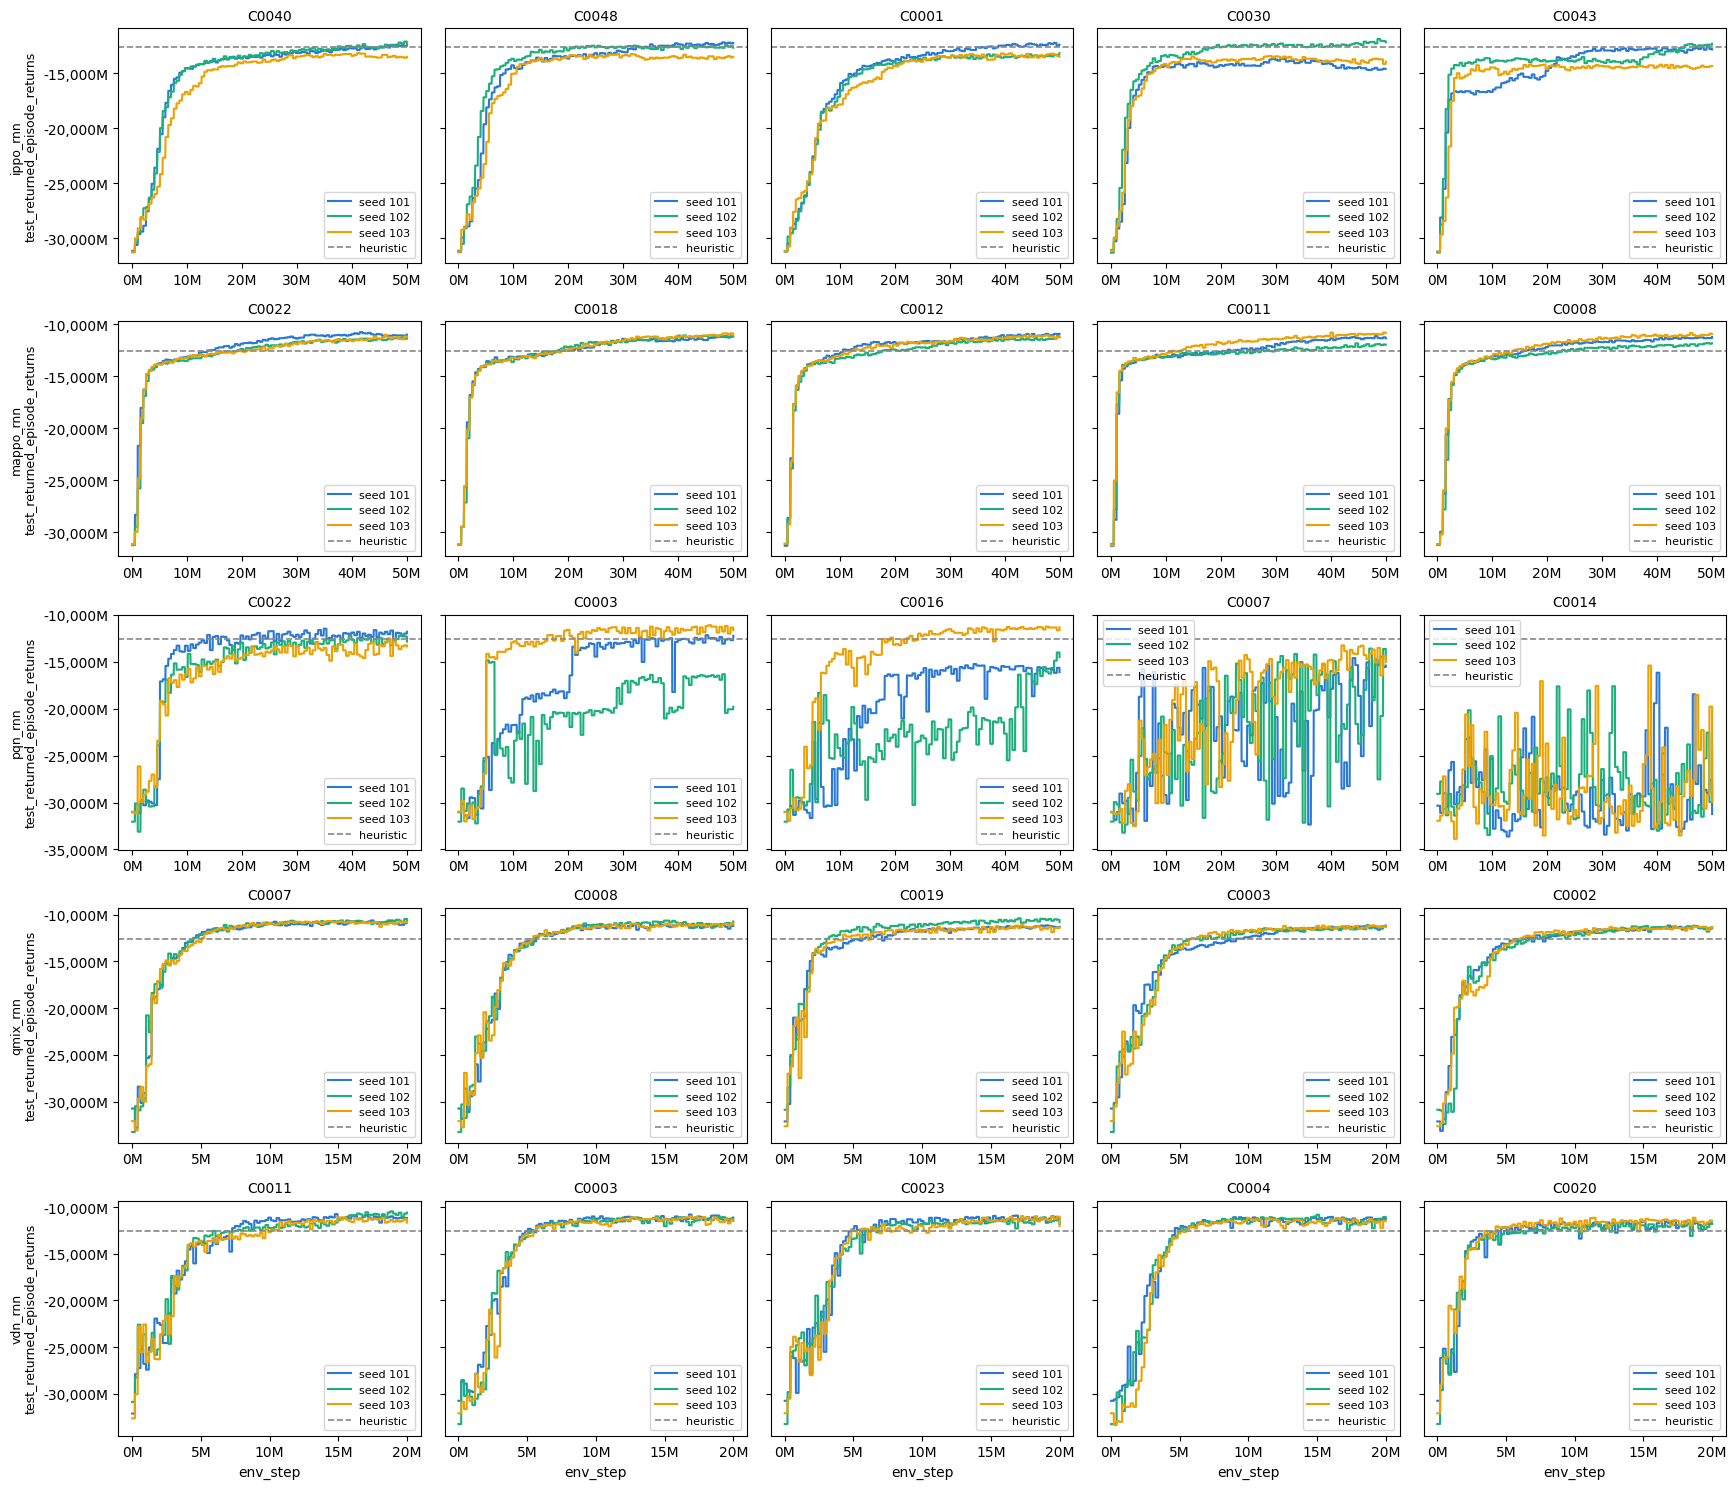

In [40]:
from matplotlib.ticker import FuncFormatter

# Fixed-order categorical palette (one hue per seed slot, never reassigned).
SEED_COLORS = ["#2a78d6", "#1baf7a", "#eda100"]
BASELINE_COLOR = "#888888"

HEURISTIC_BASELINE = -12.6e9  # heuristic baseline return (-12,600M)

millions_formatter = FuncFormatter(lambda v, _: f"{v / 1e6:,.0f}M")


def plot_combo_learning_curve(project, alg, combo_id, ax):
    combo_runs = runs_df.query(
        "project == @project and alg == @alg and combo_id == @combo_id"
    ).sort_values("run_label")

    for seed_idx, (_, r) in enumerate(combo_runs.iterrows()):
        run = loaded_runs[(project, r["run_id"])]
        x = run.get_history_values("env_step")
        y = run.get_history_values(METRIC)
        ax.plot(
            x, y,
            color=SEED_COLORS[seed_idx % len(SEED_COLORS)],
            linewidth=1.5,
            label=f"seed {r['seed']}",
        )

    ax.axhline(
        HEURISTIC_BASELINE,
        color=BASELINE_COLOR,
        linestyle="--",
        linewidth=1.2,
        label="heuristic",
    )
    ax.yaxis.set_major_formatter(millions_formatter)
    ax.xaxis.set_major_formatter(millions_formatter)
    ax.set_title(combo_id, fontsize=10)
    ax.legend(fontsize=8)


algs = list(top_combos_by_alg)
n_algs = len(algs)
fig, axes = plt.subplots(
    n_algs, TOP_N,
    figsize=(3.5 * TOP_N, 3.0 * n_algs),
    squeeze=False,
    sharex="row",
    sharey="row",
)

for row_idx, alg in enumerate(algs):
    alg_combos = top_combos_by_alg[alg]
    for col_idx in range(TOP_N):
        ax = axes[row_idx][col_idx]
        if col_idx >= len(alg_combos):
            ax.set_axis_off()
            continue
        combo = alg_combos.iloc[col_idx]
        plot_combo_learning_curve(combo["project"], alg, combo["combo_id"], ax)
        if col_idx == 0:
            ax.set_ylabel(f"{alg}\n{METRIC}", fontsize=9)

for ax in axes[-1]:
    ax.set_xlabel("env_step")

fig.tight_layout()
plt.show()

## Relative performance of the best combo per algorithm

One box per algorithm over the per-seed `best_test_return` of its rank-1 combo,
expressed relative to the heuristic baseline:
`(return − baseline) / |baseline| × 100`, so `0` = heuristic (red line) and
positive = better than the heuristic. Individual seeds are overlaid as dots,
the open diamond marks the mean, and each box is annotated with its max and
mean % improvement; the number of seeds is part of each x-axis label.

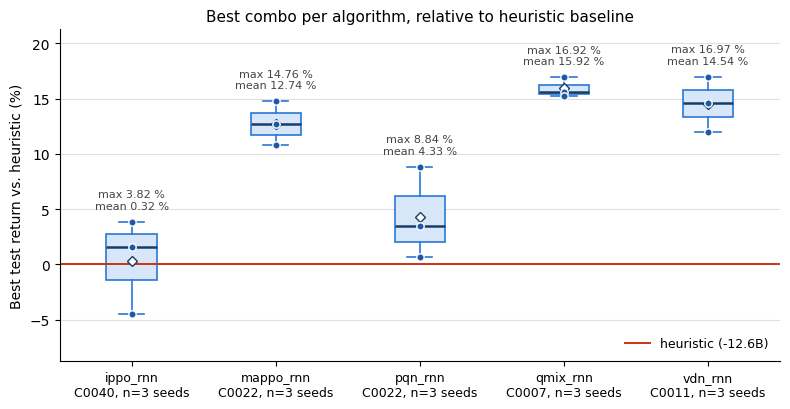

In [41]:
import numpy as np

BOX_FILL = "#d7e6f8"
BOX_EDGE = "#2a78d6"
POINT_COLOR = "#1c5aa8"
HEURISTIC_LINE_COLOR = "#cc3311"

labels, rel_perfs = [], []
for alg, alg_combos in top_combos_by_alg.items():
    best = alg_combos.iloc[0]
    seed_returns = runs_df[
        (runs_df["project"] == best["project"])
        & (runs_df["alg"] == alg)
        & (runs_df["combo_id"] == best["combo_id"])
    ]["best_test_return"]
    rel = (seed_returns - HEURISTIC_BASELINE) / abs(HEURISTIC_BASELINE) * 100
    rel_perfs.append(rel.to_numpy())
    labels.append(f"{alg}\n{best['combo_id']}, n={len(rel)} seeds")

fig, ax = plt.subplots(figsize=(1.4 * len(rel_perfs) + 1.0, 4.2))
positions = np.arange(1, len(rel_perfs) + 1)

bp = ax.boxplot(
    rel_perfs,
    positions=positions,
    widths=0.35,
    patch_artist=True,
    medianprops={"color": "#1a3d66", "linewidth": 1.8},
    whiskerprops={"color": BOX_EDGE, "linewidth": 1.2},
    capprops={"color": BOX_EDGE, "linewidth": 1.2},
    flierprops={
        "marker": "o",
        "markerfacecolor": "none",
        "markeredgecolor": BOX_EDGE,
    },
    showmeans=True,
    meanprops={
        "marker": "D",
        "markersize": 5,
        "markerfacecolor": "white",
        "markeredgecolor": "#1a3d66",
    },
)
for box in bp["boxes"]:
    box.set(facecolor=BOX_FILL, edgecolor=BOX_EDGE, linewidth=1.2)

for pos, rel in zip(positions, rel_perfs):
    ax.scatter(
        np.full(len(rel), pos),
        rel,
        s=28,
        color=POINT_COLOR,
        edgecolors="white",
        linewidths=1.0,
        zorder=3,
    )
    ax.annotate(
        f"max {rel.max():.2f} %\nmean {rel.mean():.2f} %",
        xy=(pos, rel.max()),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        color="#444444",
    )

ax.axhline(
    0,
    color=HEURISTIC_LINE_COLOR,
    linewidth=1.4,
    label=f"heuristic ({HEURISTIC_BASELINE / 1e9:.1f}B)",
)
ax.margins(y=0.2)  # headroom for the max/mean annotations

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Best test return vs. heuristic (%)")
ax.set_title("Best combo per algorithm, relative to heuristic baseline", fontsize=11)
ax.yaxis.grid(True, color="#e0e0e0", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.legend(fontsize=9, loc="lower right", frameon=False)

fig.tight_layout()
plt.show()

## Hyperparameter sensitivity

One panel per swept hyperparameter (any config key with more than one value
within an algorithm's sweep, bookkeeping keys excluded), one figure per
algorithm. Each dot is one combo: its `best_test_return` pooled across the
combo's seeds with `SEED_AGG` (mean or median, set at the top of the cell),
jittered at the combo's value of that parameter, with a black bar at the
median over combos. A parameter whose medians are flat across values has
little marginal effect; a shifted median — or a value whose combos never
collapse to very low returns — marks a value that matters. Note these are
marginal views over the whole sweep, so a parameter's effect can be masked
by the values of the others.

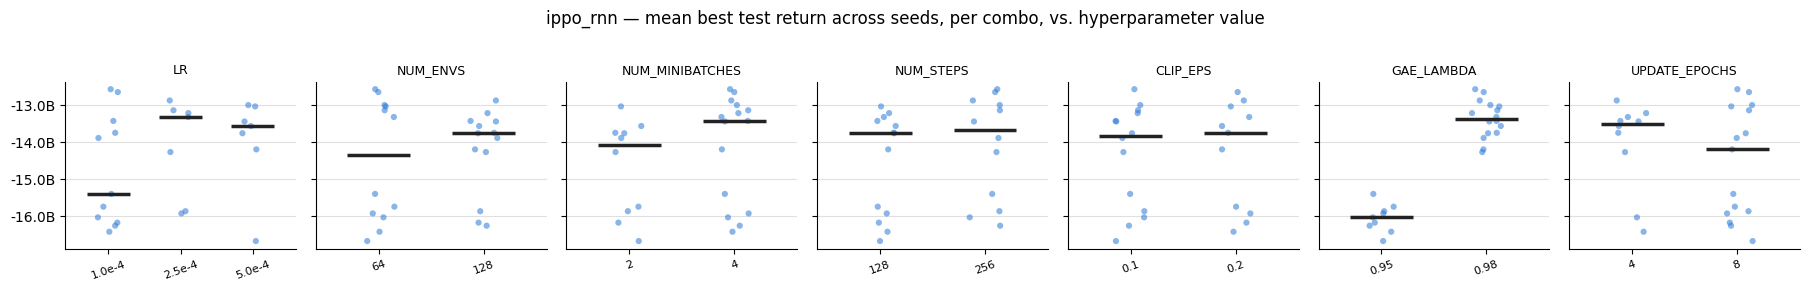

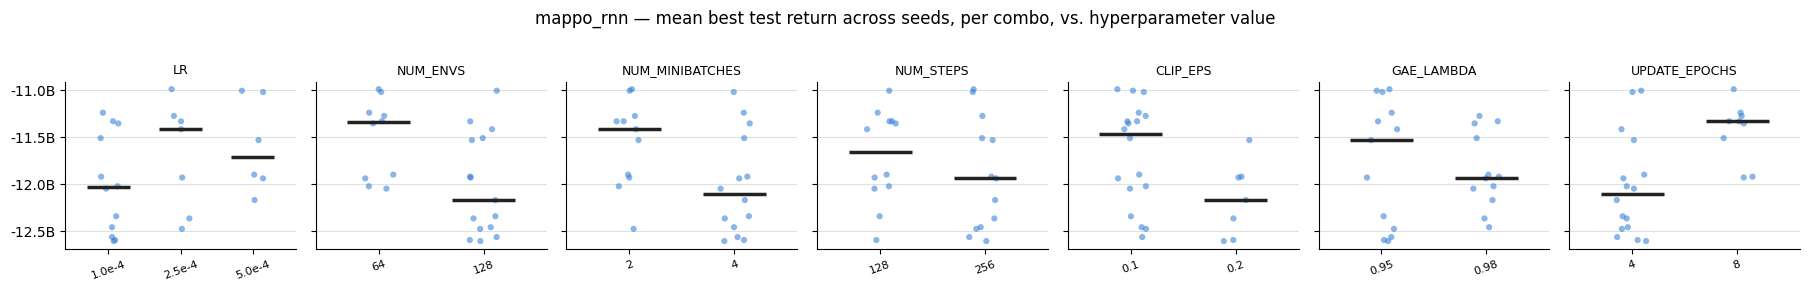

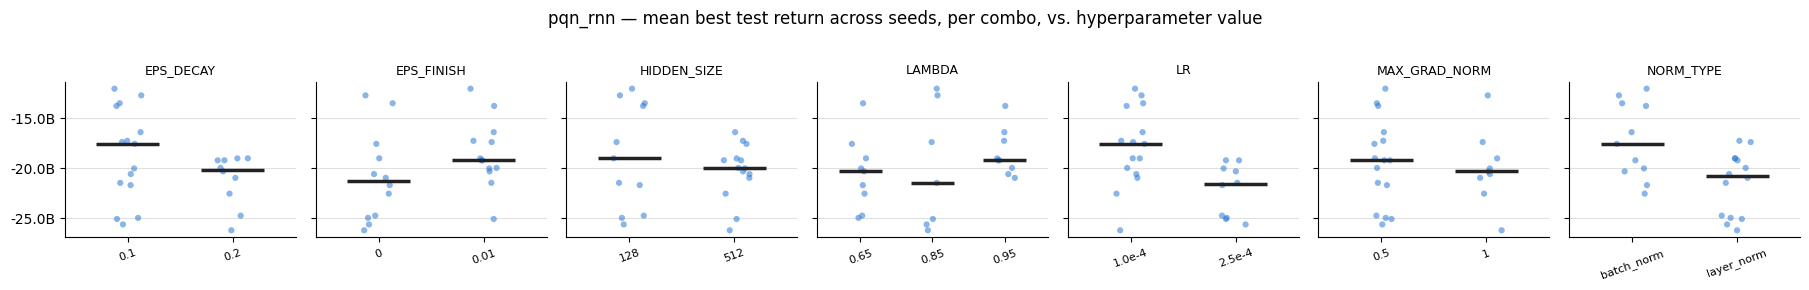

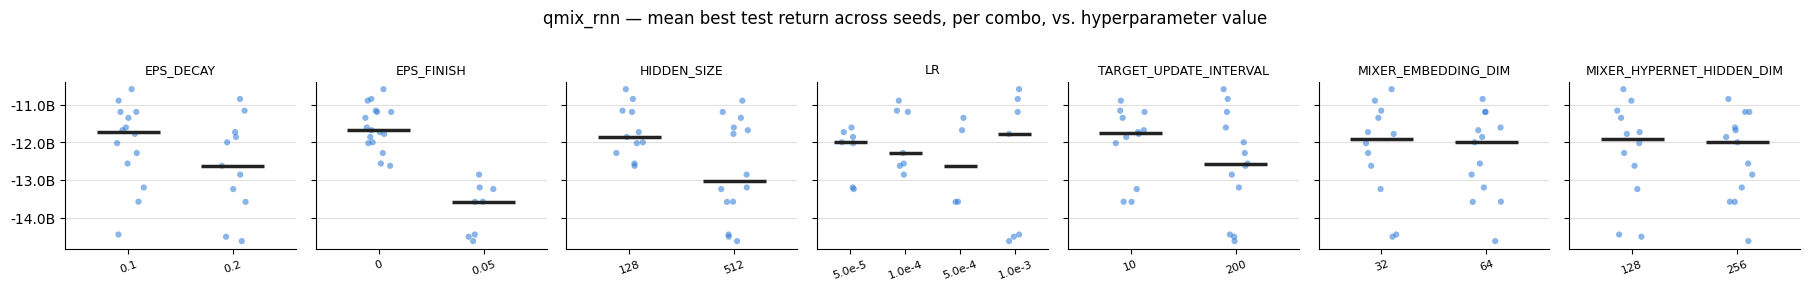

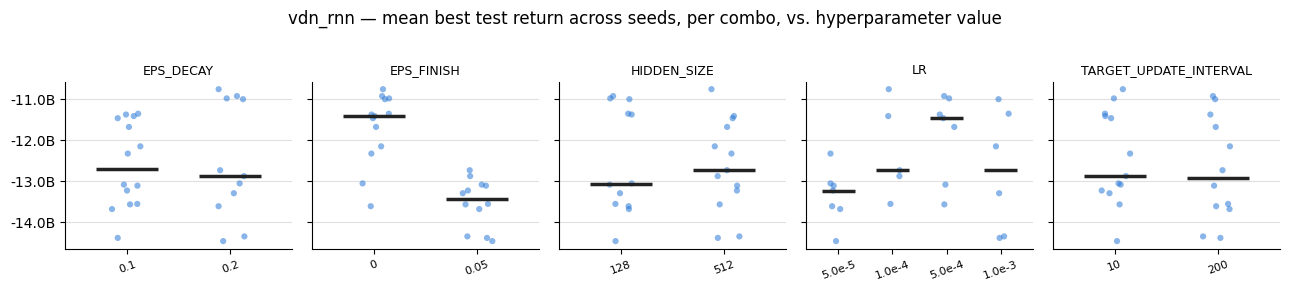

In [46]:
SEED_AGG = "mean"  # how to pool best_test_return across a combo's seeds: "mean" | "median"

DOT_COLOR = "#2a78d6"
MEDIAN_COLOR = "#222222"

billions_formatter = FuncFormatter(lambda v, _: f"{v / 1e9:,.1f}B")
rng = np.random.default_rng(0)


def format_hp_value(v):
    if isinstance(v, bool):
        return str(v)
    if isinstance(v, float) and v != 0 and abs(v) < 1e-2:
        return f"{v:.1e}".replace("e-0", "e-")  # 0.0001 -> 1.0e-4
    if isinstance(v, (int, float)):
        return f"{v:g}"
    return str(v)


# One row per run with its full hyperparameter config attached, then pooled
# to one row per combo (hyperparameters are identical across a combo's seeds).
hp_df = pd.DataFrame(
    {
        "alg": r.alg,
        "project": r.project,
        "combo_id": r.combo_id,
        "best_test_return": r.best_test_return,
        **{
            k: v
            for k, v in loaded_runs[(r.project, r.run_id)].config.items()
            if k not in NON_HYPERPARAM_KEYS
        },
    }
    for r in runs_df.itertuples()
)
combo_hp_df = hp_df.groupby(["alg", "project", "combo_id"], as_index=False).agg(
    {
        col: SEED_AGG if col == "best_test_return" else "first"
        for col in hp_df.columns.drop(["alg", "project", "combo_id"])
    }
)

for alg, alg_df in combo_hp_df.groupby("alg"):
    alg_df = alg_df.dropna(axis=1, how="all")
    swept = [
        col
        for col in alg_df.columns.drop(["alg", "project", "combo_id", "best_test_return"])
        if alg_df[col].nunique() > 1
    ]
    if not swept:
        print(f"{alg}: no swept hyperparameters found")
        continue

    fig, axes = plt.subplots(
        1, len(swept),
        figsize=(2.6 * len(swept), 2.8),
        sharey=True,
        squeeze=False,
    )

    for ax, param in zip(axes.flat, swept):
        values = sorted(alg_df[param].unique())
        for i, val in enumerate(values):
            y = alg_df.loc[alg_df[param] == val, "best_test_return"]
            ax.scatter(
                i + rng.uniform(-0.15, 0.15, len(y)),
                y,
                s=20,
                color=DOT_COLOR,
                alpha=0.55,
                edgecolors="none",
            )
            ax.hlines(
                y.median(), i - 0.3, i + 0.3,
                color=MEDIAN_COLOR, linewidth=2.5, zorder=3,
            )
        ax.set_xticks(range(len(values)))
        ax.set_xticklabels(
            [format_hp_value(v) for v in values], rotation=20, fontsize=8
        )
        ax.set_xlim(-0.6, len(values) - 0.4)
        ax.set_title(param, fontsize=9)
        ax.yaxis.set_major_formatter(billions_formatter)
        ax.yaxis.grid(True, color="#e0e0e0", linewidth=0.8)
        ax.set_axisbelow(True)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)

    fig.suptitle(
        f"{alg} — {SEED_AGG} best test return across seeds, "
        "per combo, vs. hyperparameter value",
        y=1.02,
    )
    fig.tight_layout()
    plt.show()